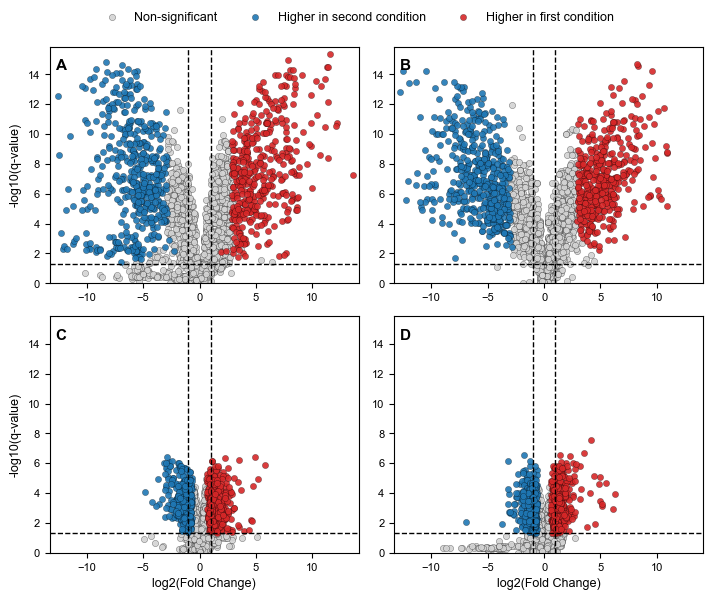

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# LOAD DATA
# -------------------------
df_A = pd.read_excel("C:/Users/tamer/Documents/PhD/ML/Volcano/control1_control2_Volcano.xlsx")
df_B = pd.read_excel("C:/Users/tamer/Documents/PhD/ML/Volcano/treatment1_treatment2_Volcano.xlsx")
df_C = pd.read_excel("C:/Users/tamer/Documents/PhD/ML/Volcano/treatment1_control1_Volcano.xlsx")
df_D = pd.read_excel("C:/Users/tamer/Documents/PhD/ML/Volcano/treatment2_control2_Volcano.xlsx")

dfs = [df_A, df_B, df_C, df_D]
titles = ["A", "B", "C", "D"]

# -------------------------
# STYLE
# -------------------------
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

# -------------------------
# COLORS
# -------------------------
colors = {
    "Up": "#d62728",
    "Down": "#1f77b4",
    "Non-significant": "lightgrey"
}

# -------------------------
# FIGURE (2x2 panel)
# -------------------------
fig, axes = plt.subplots(2, 2, figsize=(7.2, 6))

axes = axes.flatten()

# -------------------------
# GLOBAL AXIS LIMITS (important)
# -------------------------
all_x = pd.concat([df["log2.Fold.Change."] for df in dfs])
all_y = pd.concat([df["log_qvalue"] for df in dfs])

xlim = (all_x.min() - 0.5, all_x.max() + 0.5)
ylim = (0, all_y.max() + 0.5)

# -------------------------
# PLOT EACH PANEL
# -------------------------
for i, (df, ax) in enumerate(zip(dfs, axes)):
    
    for state in ["Non-significant", "Down", "Up"]:
        subset = df[df["State"] == state]

        ax.scatter(
            subset["log2.Fold.Change."],
            subset["log_qvalue"],
            c=colors[state],
            s=20,
            edgecolor="black",
            linewidth=0.2,
            alpha=0.9,
            label=state if i == 0 else ""  # legend only once
        )

    # thresholds
    ax.axvline(x=1, linestyle="--", color="black", linewidth=1)
    ax.axvline(x=-1, linestyle="--", color="black", linewidth=1)
    ax.axhline(y=1.3, linestyle="--", color="black", linewidth=1)

    # limits
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # panel label (A, B, C, D)
    ax.text(0.02, 0.95, titles[i],
            transform=ax.transAxes,
            fontsize=11,
            fontweight="bold",
            va="top")

    # axis labels only on edges
    if i in [2, 3]:
        ax.set_xlabel("log2(Fold Change)")
    else:
        ax.set_xlabel("")

    if i in [0, 2]:
        ax.set_ylabel("-log10(q-value)")
    else:
        ax.set_ylabel("")

# -------------------------
# LEGEND (global)
# -------------------------
handles, labels = axes[0].get_legend_handles_labels()

label_map = {
    "Down": "Higher in second condition",
    "Up": "Higher in first condition",
    "Non-significant": "Non-significant"
}

new_labels = [label_map[l] for l in labels]

fig.legend(handles, new_labels,
           loc="upper center",
           ncol=3,
           frameon=False)

# -------------------------
# LAYOUT
# -------------------------
plt.tight_layout(rect=[0, 0, 1, 0.95])

# -------------------------
# SAVE
# -------------------------
plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/volcano/volcano_panel.tif",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "C:/Users/tamer/Documents/PhD/ML/volcano/volcano_panel.pdf",
    bbox_inches="tight"
)

plt.show()